# Breast Cancer Novelty Detection with One-Class SVM

This example adapts the breast-cancer forward-selection workflow to `sklearn.svm.OneClassSVM`. Benign observations define the learned **inlier** distribution (`+1`); malignant observations are treated as known novelties (`-1`) for validation and blind-set evaluation. Malignant observations are never used to fit the one-class models.

## Import packages/modules

In [1]:
from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_ocsvm, svmSet

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

## Import dataset

In [2]:
data_table = pd.read_csv("wdbc.data", header=None)
properties = [
    "Radius", "Texture", "Perimeter", "Area", "Smoothness",
    "Compactness", "Concavity", "Concave Points", "Symmetry",
    "Fractal Dimension",
]
feature_names = (
    [p + " mean" for p in properties]
    + [p + " SE" for p in properties]
    + [p + " worst" for p in properties]
)
data_table.columns = pd.Index(["ID", "Diagnosis"] + feature_names)
data_table.head()

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave Points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave Points worst,Symmetry worst,Fractal Dimension worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Create development and blind sets

Split before scaling. The scaler is fitted only on benign development observations so preprocessing also represents the normal population.

In [3]:
X_raw = data_table[feature_names]
y = data_table["Diagnosis"].map({"B": 1, "M": -1}).astype(int)

X_development_raw, X_blind_raw, y_development, y_blind = train_test_split(
    X_raw,
    y,
    stratify=y,
    random_state=0,
    test_size=0.20,
)

scaler = StandardScaler().fit(X_development_raw.loc[y_development == 1])
X_development = scaler.transform(X_development_raw)
X_blind = scaler.transform(X_blind_raw)

pd.Series(y_development).value_counts().rename(index={1: "inlier (+1)", -1: "outlier (-1)"})

Diagnosis
inlier (+1)     285
outlier (-1)    170
Name: count, dtype: int64

## Define one-class validation sets

Each member trains only on benign observations. Its validation set contains held-out benign observations plus all available malignant development observations.

In [4]:
cv_set = cvSet(X=X_development, y=y_development.to_numpy())
cv_set.one_class(num_sets=5, validation_size=0.20, random_seed=0)

assert all(np.all(cv_set.y[indices] == 1) for indices in cv_set.train)
[(len(train), len(test)) for train, test in zip(cv_set.train, cv_set.test)]

[(228, 227), (228, 227), (228, 227), (228, 227), (228, 227)]

## Initialize OneClassSVM and parameter grid

In [5]:
ocsvm = OneClassSVM(kernel="precomputed", tol=1e-12)

nu_range = [0.02, 0.05, 0.10]
gamma_range = [2**x for x in range(-7, -2)]
parameter_grid = [
    paramSet(model={"nu": nu}, kernel={"gamma": gamma})
    for nu in nu_range
    for gamma in gamma_range
]
len(parameter_grid)

15

## Forward feature selection

The workflow mirrors the SVC example. `score_ocsvm` combines validation ROC AUC and inlier F1. For OneClassSVM, `combined_rank` negates the cumulative squared decision perturbation, so selection favors features that disturb the decision function less; it combines that rank with the One-Class SVM quadratic-objective perturbation.

In [6]:
kernel_type = "rbf"
rank_weights = [0.75, 0.90, 1.00]

svm_set_ranks = []
for rank_weight in rank_weights:
    print(f"Rank weight: {rank_weight:.2f}")
    model = svmSet(
        ocsvm,
        cv_set,
        score_method=score_ocsvm().score,
        kernel=kernelWrapper(type=kernel_type),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    model.greedy_forward_selection(
        parameter_grid=parameter_grid,
        addition_factor=0.10,
        max_features=15,
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="train",
        tune_models_each_step=True,
    )
    svm_set_ranks.append(model)

Rank weight: 0.75
Number of Features: 1, Score: 0.876
Number of Features: 3, Score: 0.864
Number of Features: 5, Score: 0.858
Number of Features: 7, Score: 0.857
Number of Features: 9, Score: 0.866
Number of Features: 11, Score: 0.880
Number of Features: 12, Score: 0.881
Number of Features: 13, Score: 0.882
Number of Features: 14, Score: 0.880
Number of Features: 15, Score: 0.881
Number of Features: 30, Score: 0.913
Rank weight: 0.90
Number of Features: 1, Score: 0.876
Number of Features: 3, Score: 0.855
Number of Features: 5, Score: 0.858
Number of Features: 7, Score: 0.864
Number of Features: 9, Score: 0.881
Number of Features: 11, Score: 0.865
Number of Features: 12, Score: 0.865
Number of Features: 13, Score: 0.870
Number of Features: 14, Score: 0.870
Number of Features: 15, Score: 0.879
Number of Features: 30, Score: 0.913
Rank weight: 1.00
Number of Features: 1, Score: 0.876
Number of Features: 3, Score: 0.855
Number of Features: 5, Score: 0.858
Number of Features: 7, Score: 0.85

## Feature-selection performance curves

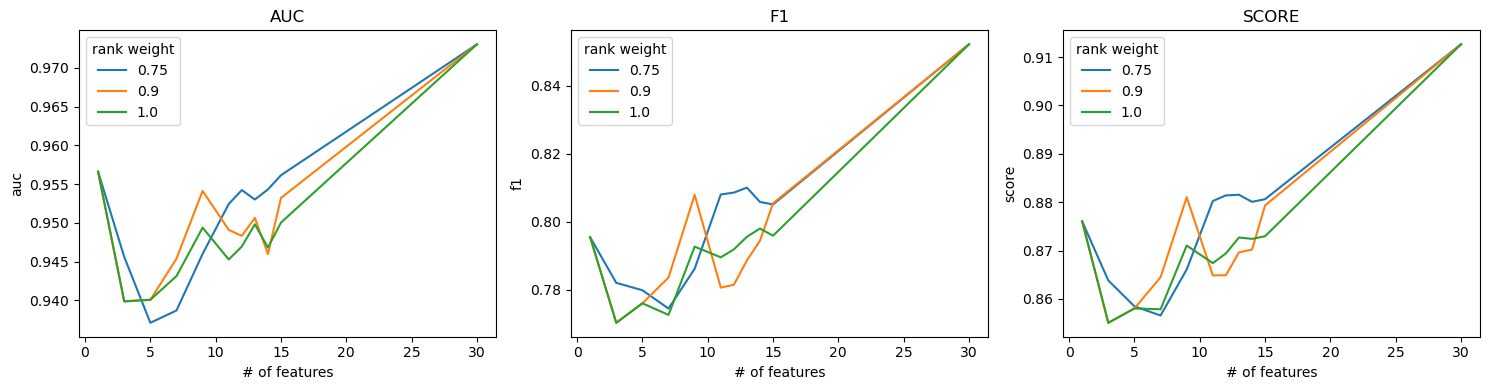

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for model, rank_weight in zip(svm_set_ranks, rank_weights):
    for ax, metric in zip(axes, ["auc", "f1", "score"]):
        plt.sca(ax)
        model.plot_performance(metric=metric)
        ax.set_title(metric.upper())
for ax in axes:
    ax.legend(rank_weights, title="rank weight")
plt.tight_layout()

## Select the strongest feature-selection run

In [8]:
enrichment_scores = [model.enrichment_score() for model in svm_set_ranks]
selected_run = int(np.argmax(enrichment_scores))
best_model = svm_set_ranks[selected_run]

pd.DataFrame({"rank_weight": rank_weights, "enrichment_score": enrichment_scores})

,rank_weight,enrichment_score
0,0.75,0.853973
1,0.90,0.852493
2,1.00,0.850143


## Blind-set novelty-detection performance

Decision values above zero are inliers. Negative values are predicted novelties.

In [9]:
decision_values = best_model.decision_function(X_blind)
y_pred = best_model.predict(X_blind)

tn, fp, fn, tp = confusion_matrix(y_blind, y_pred, labels=[-1, 1]).ravel()
blind_results = {
    "rank_weight": rank_weights[selected_run],
    "mean_member_features": np.mean([len(features) for features in best_model.features]),
    "f1_inlier": f1_score(y_blind, y_pred, pos_label=1),
    "auc_inlier": roc_auc_score(y_blind, decision_values),
    "outlier_recall": tn / (tn + fp),
    "inlier_recall": tp / (tp + fn),
}
blind_results

{'rank_weight': 0.75,
 'mean_member_features': 11.0,
 'f1_inlier': 0.8571428571428571,
 'auc_inlier': 0.91005291005291,
 'outlier_recall': 0.9047619047619048,
 'inlier_recall': 0.7916666666666666}

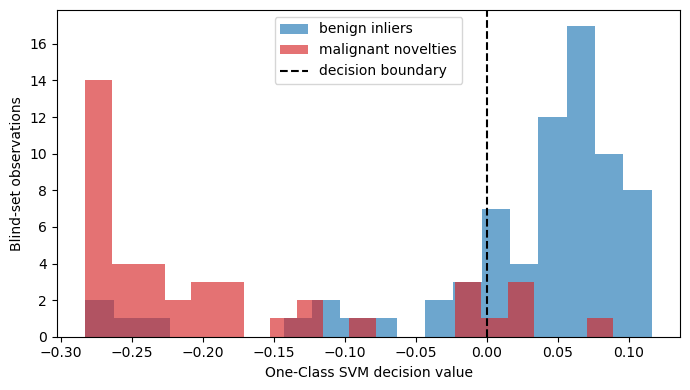

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, name, color in [(1, "benign inliers", "tab:blue"), (-1, "malignant novelties", "tab:red")]:
    ax.hist(decision_values[y_blind.to_numpy() == label], bins=20, alpha=0.65, label=name, color=color)
ax.axvline(0, color="black", linestyle="--", label="decision boundary")
ax.set_xlabel("One-Class SVM decision value")
ax.set_ylabel("Blind-set observations")
ax.legend()
plt.tight_layout()

## Perturbation-based contribution and importance

For feature group $g$, `decision_perturbation_` returns

$$C_g(x)=f(x)-f_{-g}(x).$$

Positive values move an observation toward the inlier region; negative values move it toward novelty. `feature_importance_` returns the magnitude of the frozen-coefficient quadratic change $\tfrac12\alpha^T(K-K_{-g})\alpha$ for OneClassSVM only.

In [11]:
member_index = 0
contributions = best_model.decision_perturbation_(member_index, X_blind)
importance = best_model.feature_importance_(member_index)
active_groups = best_model._active_perturbation_sets(member_index)

perturbation_summary = pd.DataFrame({
    "feature": [feature_names[group[0]] for group in active_groups],
    "mean_signed_contribution": contributions.mean(axis=0),
    "mean_squared_contribution": np.mean(contributions**2, axis=0),
    "objective_importance": importance,
}).sort_values("mean_squared_contribution", ascending=False)
perturbation_summary

,feature,mean_signed_contribution,mean_squared_contribution,objective_importance
7,Fractal Dimension SE,-0.322981,0.115595,0.762164
5,Texture SE,-0.201419,0.046427,0.468413
4,Fractal Dimension mean,-0.187645,0.037185,0.389950
3,Concave Points mean,-0.154309,0.035860,0.229463
6,Perimeter SE,-0.095958,0.025332,0.093701
10,Concave Points worst,-0.121589,0.023585,0.097604
2,Compactness mean,-0.137686,0.020036,0.306271
9,Smoothness worst,-0.112218,0.013613,0.293057
1,Smoothness mean,-0.072774,0.006624,0.165762
8,Texture worst,-0.065253,0.005884,0.129760


## Integrated-gradient attributions

The default reference is optimized onto each member's zero-valued one-class boundary. To keep this example quick, visualize a stratified subset of the blind observations.

In [12]:
rng = np.random.default_rng(0)
explanation_indices = np.concatenate([
    rng.choice(np.flatnonzero(y_blind.to_numpy() == label), size=12, replace=False)
    for label in (-1, 1)
])

ig_result = best_model.explain_integrated_gradients(
    X_blind[explanation_indices],
    feature_names=feature_names,
    target=y_blind.to_numpy()[explanation_indices],
    model_index=None,
    num_steps=20,
)

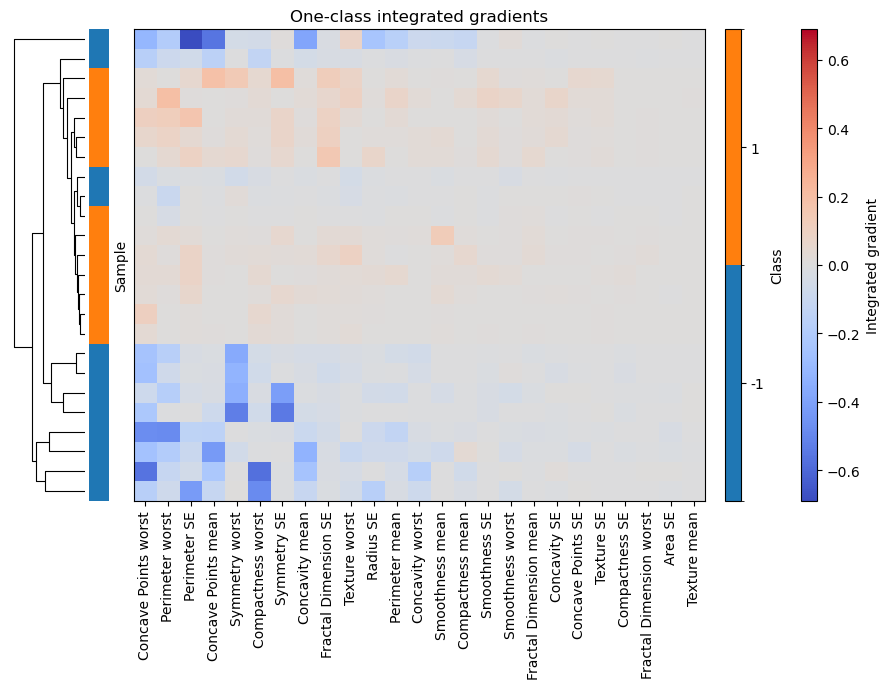

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
ig_result.heatmap(
    ax=ax,
    cluster=True,
    cmap="coolwarm",
    imshow_kwargs={"rasterized": True},
    target_strip_width=0.20,
    strip_pad=0.25,
    colorbar_width=0.16,
    colorbar_pad=0.2,
    colorbar_gap=0.6,
)
ax.set_title("One-class integrated gradients")
plt.tight_layout()

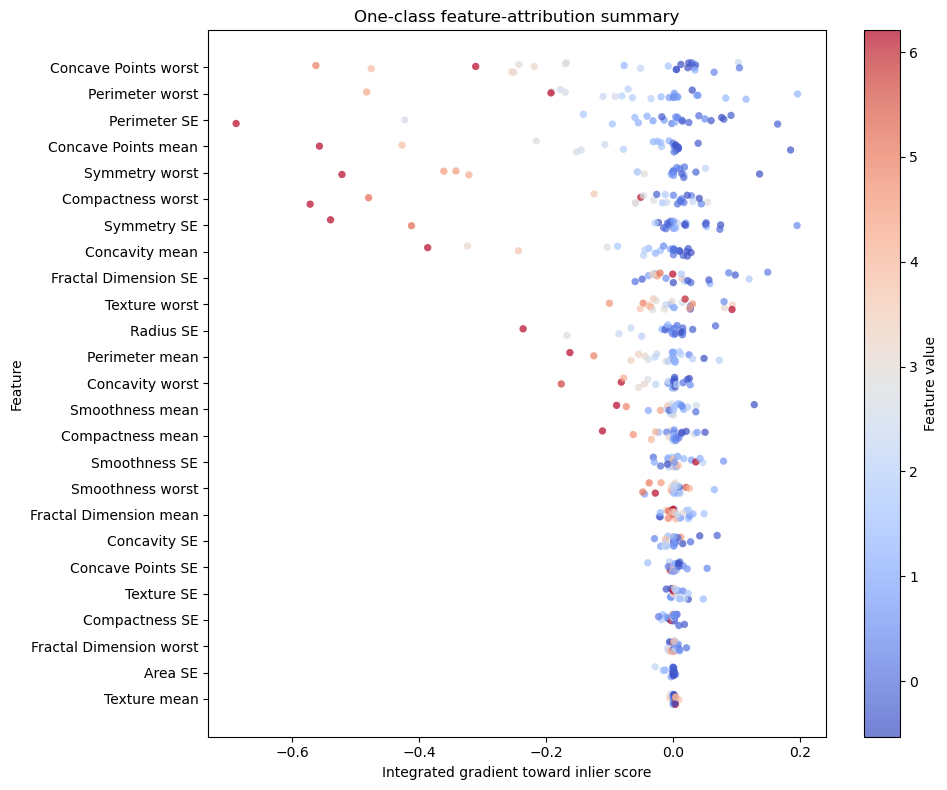

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ig_result.summary_plot(
    ax=ax,
    max_features=20,
    cmap="coolwarm",
    random_state=0,
    scatter_kwargs={"s": 28, "alpha": 0.7, "edgecolors": "none"},
)
ax.set_title("One-class feature-attribution summary")
ax.set_xlabel("Integrated gradient toward inlier score")
plt.tight_layout()